# Run EPEDNN for just SPARC unmodified, see if you get the expected answer

In [11]:
import os
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from scipy.interpolate import interp1d
import sys
from pathlib import Path
import tempfile
import urllib.request # needed for geqdsk import
ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(ROOT))
from src.profiles_loop_solve import profiles_loop_solve
from src.solver_nondim import saarelma_connor_nondim


tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, read_eqdsk

from examples.device_prediction.helper_functions import read_sparcpublic_profiles, psi_n_and_rho_psi, build_manual_profs, calc_pressure_profile, _print_profile_summary, read_popcon, _to_watts

In [2]:
# Import the SPARC baseline scenario geqdsk (freely available from SPARCPublic)
import urllib.parse

_SPARC_PRD = 'https://raw.githubusercontent.com/cfs-energy/SPARCPublic/main/PrimaryReferenceDischarge'
_SPARC_GEQDSK = '2 - SPARC_DN_PRD_freegs_20221013'


def fetch_text(filename):
    """Read a file from the SPARCPublic PRD folder over HTTP."""
    url = f'{_SPARC_PRD}/{urllib.parse.quote(filename)}'
    print(f'Fetching {filename} from SPARCPublic...', end=' ', flush=True)
    with urllib.request.urlopen(url) as resp:
        text = resp.read().decode()
    print('done.')
    return text


# Persist gEQDSK for mhd_load / profiles_loop_solve (needs a filepath).
# Leading 'g' keeps equil_tag = Path(mhd_fp).name[1:] sensible.
mhd_fp = 'gSPARC_DN_PRD.geqdsk'
geqdsk_text = fetch_text(_SPARC_GEQDSK)
Path(mhd_fp).write_text(geqdsk_text)
print(f'Wrote {mhd_fp}')

eqdsk = read_eqdsk(mhd_fp)

print(f"  Ip      = {eqdsk['ip']/1.E6:.2f} MA")
print(f"  F0      = {eqdsk['rcentr']*eqdsk['bcentr']:.2f} T.m  (B0 = {eqdsk['rcentr']*eqdsk['bcentr']/1.85:.2f} T at R0 = 1.85 m)")
print(f"  p_axis  = {eqdsk['pres'][0]/1.E6:.2f} MPa")
print(f"  axis    = ({eqdsk['raxis']:.3f}, {eqdsk['zaxis']:.3f}) m")


Fetching 2 - SPARC_DN_PRD_freegs_20221013 from SPARCPublic... done.
Wrote gSPARC_DN_PRD.geqdsk
  Ip      = 8.70 MA
  F0      = 22.49 T.m  (B0 = 12.16 T at R0 = 1.85 m)
  p_axis  = 2.60 MPa
  axis    = (1.890, -0.000) m


Using 6 - cgyro_20221013.txt (cgyro) for manual_profs
Loaded 6 - cgyro_20221013.txt (cgyro): 201 points
  quantities: ['rho', 'polflux', 'q', 'Te', 'Ti', 'ne']
  psi_N mapping: using polflux -> rho_psi=sqrt(psi_N) (max |rho_file^2 - psi_N| = 0.202)
  Te axis  = 23.42 keV,  edge = 0.27 keV
  ne axis  = 4.96e20 m^-3,  edge = 0.85e20 m^-3
  Ti axis  = 17.13 keV,  edge = 0.58 keV
  ni: not in file


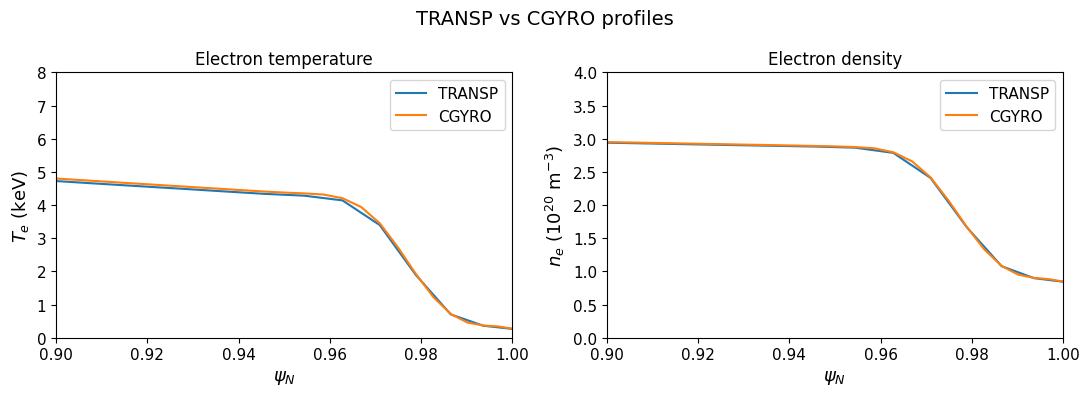

In [3]:
# Import SPARC kinetic profiles from local SPARCPublic exports.
# TRANSP: 5 - transp_20221013.txt
# CGYRO:  6 - cgyro_20221013.txt
# Sections: rho, polflux, q, te [keV], ti [keV], ne [10^19/m^3] (ni optional).

TRANSP_PATH = Path('5 - transp_20221013.txt')
CGYRO_PATH = Path('6 - cgyro_20221013.txt')
PROFILE_SOURCE = 'cgyro'   # 'transp' or 'cgyro' — feeds manual_profs for the solve
OVERPLOT_PROFILES = True   # if True, plot TRANSP and CGYRO together for comparison


read_transp_profiles = read_sparcpublic_profiles
read_cgyro_profiles = read_sparcpublic_profiles

profiles_transp = read_transp_profiles(TRANSP_PATH)
profiles_cgyro = read_cgyro_profiles(CGYRO_PATH)

source = PROFILE_SOURCE.strip().lower()
if source == 'transp':
    profiles = profiles_transp
    prof_path = TRANSP_PATH
elif source == 'cgyro':
    profiles = profiles_cgyro
    prof_path = CGYRO_PATH
else:
    raise ValueError(f"PROFILE_SOURCE must be 'transp' or 'cgyro', got {PROFILE_SOURCE!r}")

manual_profs = build_manual_profs(profiles)

print(f'Using {prof_path.name} ({source}) for manual_profs')
_print_profile_summary(source, prof_path, profiles)

if OVERPLOT_PROFILES:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
    for ax, qty, ylabel in zip(
        axes,
        ('Te', 'ne'),
        (r'$T_e$ (keV)', r'$n_e$ ($10^{20}$ m$^{-3}$)'),
    ):
        for label, prof, color in (
            ('TRANSP', profiles_transp, 'C0'),
            ('CGYRO', profiles_cgyro, 'C1'),
        ):
            psi_N, _ = psi_n_and_rho_psi(prof)
            y = prof[qty] if qty == 'Te' else prof[qty] / 1e20
            ax.plot(psi_N, y, '-', color=color, label=label)
        ax.set_xlabel(r'$\psi_N$', fontsize=13)
        ax.set_ylabel(ylabel, fontsize=13)
        ax.legend(fontsize=11)
        ax.tick_params(labelsize=11)
        ax.set_xlim(0.9, 1)
    axes[0].set_ylim(0, 8)
    axes[1].set_ylim(0, 4)
    axes[0].set_title('Electron temperature')
    axes[1].set_title('Electron density')
    fig.suptitle('TRANSP vs CGYRO profiles', fontsize=14)
    plt.tight_layout()
    plt.show()


In [4]:
# Import heating power and Zeff from SPARCPublic POPCON table
POPCON_PATH = Path('1 - PRD_POPCON_20221013.csv')


popcon = read_popcon(POPCON_PATH, keys=('Ohmic power', 'RF power', 'Zeff'))

P_ohmic = _to_watts(popcon['Ohmic power']['value'], popcon['Ohmic power']['unit'])  # W
P_RF = _to_watts(popcon['RF power']['value'], popcon['RF power']['unit'])            # W
Zeff = float(popcon['Zeff']['value'])  # dimensionless

# P_tot_e: heating power to electrons [W].
# Saarelma et al. take ~half of the total (Ohmic+RF) heating as electron channel.
P_tot_e = (P_ohmic + P_RF) / 2

print(f'Loaded POPCON inputs from {POPCON_PATH.name}:')
print(f'  P_ohmic = {P_ohmic/1e6:.2f} MW')
print(f'  P_RF    = {P_RF/1e6:.2f} MW')
print(f'  P_tot_e = {P_tot_e/1e6:.2f} MW  (= 0.5*(P_ohmic+P_RF), in W: {P_tot_e:.3e})')
print(f'  Zeff    = {Zeff:.3g}')


Loaded POPCON inputs from 1 - PRD_POPCON_20221013.csv:
  P_ohmic = 1.70 MW
  P_RF    = 11.10 MW
  P_tot_e = 6.40 MW  (= 0.5*(P_ohmic+P_RF), in W: 6.400e+06)
  Zeff    = 1.5


In [5]:
base_model = saarelma_connor_nondim(
        P_tot_e      = P_tot_e,
        species      = 'D-T',
        Z_i          = Zeff,
        alpha_crit   = 1,
        C_KBM        = 1,
        De_chie_etg  = 1,
        nFC_x0       = 1,
        ncx_x0_ratio = 1,
        psi_N_inner_boundary = 0.85,
        mhd_fp       = mhd_fp,
        kprof_loc    = 'manual psi_N grid',
        verbose      = False,
        manual_profs = manual_profs, # only used if kprof_loc is set so they are
)

In [6]:
epednn_model = 'EPED_SPARC'
base_model.setup_epednn(model=epednn_model)

Setting up EPEDNN...


I0000 00:00:1788287980.911362 2741366 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788287980.912961 2741366 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788287980.962139 2741366 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788287982.177826 2741366 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [13]:
'''
inputs = {
    "a": float(self.a),               # Minor radius (m)
    "betan": float(self.betan[0]),    # Normalized beta
    "bt": float(abs(self.bt[0])),     # Toroidal magnetic field at the magnetic axis (T)
    "delta": float(self.delta),       # Effective triangularity
    "ip": float(abs(self.Ip)),        # Plasma current (MA)
    "kappa": float(self.kappa),       # Elongation
    "m": float(self.M_eff),           # Effective mass (must be 2.0 for D or 2.5 for D-T)
    "neped": float(ne_ped_h),         # Pedestal density (in 10^19 m^-3)
    "r": float(self.Rmajor),          # Major radius (m)
    "zeffped": float(self.Z_i)        # Effective charge
}
'''
# manual_profs['ne'] is in 10^20 m^-3 (build_manual_profs divides by 1e20 for
# kprof_loc='manual psi_N grid'); feed_epednn wants n_e in m^-3 on x_ne, and
# interpolates it to x_inner itself.
ne_ped = np.asarray(manual_profs['ne']) * 1e20  # 10^20 m^-3 -> m^-3

In [14]:
base_model.setup_solver_grids()
interp_x = interp1d(base_model.psi_N_pres, base_model.x_prev, kind='linear', bounds_error=False, fill_value='extrapolate')
x_grid = interp_x(manual_profs['psi_N_ne'])

In [15]:
pedestal_height, pedestal_width, betan = base_model.feed_epednn(model=epednn_model, ne_ped=ne_ped, x_ne=x_grid, EPEDNN_core='pfile')

betan: [1.14878909]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step
[4.3049927e+02 5.2376766e-02]


In [17]:
print('Pedestal height [MPa]: ',pedestal_height)
print('Pedestal top location [psi_N]: ',1-pedestal_width)

Pedestal height [MPa]:  0.43049926
Pedestal top location [psi_N]:  0.94762325
